# 信贷违约预测：正则化、降维与评估指标

这个 Notebook 用一组信贷数据演示违约预测的基本流程。内容包括：

1. **数据探索与预处理**
2. **正则化回归**：Ridge、Lasso、Elastic Net
3. **降维方法**：PCR、PLS
4. **分类评估指标**：混淆矩阵、准确率、精确率、召回率、F1、AUC
5. **交叉验证与模型选择**

## Notebook 阅读路线图

这个 Notebook 可以看成银行风控建模的一个简化流程：先拿到客户数据，检查数据是否可靠，再把变量整理成模型能处理的形式；接着训练不同模型，最后用分类指标和交叉验证判断模型是否稳定、是否适合业务使用。

整体流程如下：

```text
原始信贷数据
  ↓
数据探索：查看变量分布、违约率和相关性
  ↓
数据预处理：标准化数值变量、编码分类变量、划分训练集和测试集
  ↓
模型训练：Ridge / Lasso / Elastic Net / PCR / PLS / Logistic Regression
  ↓
模型评估：混淆矩阵、Precision、Recall、F1、AUC
  ↓
交叉验证与调参：检验模型稳定性，选择合适的超参数
  ↓
业务解释：识别关键风险因素，形成风控建议
```

阅读时可以抓住三个问题：

1. **为什么要做这一步？** 例如，标准化是为了让不同量纲的变量可以放在同一个模型中比较。
2. **这一步的输入和输出是什么？** 例如，预处理的输入是原始 `X`，输出是模型可以识别的数值矩阵。
3. **结果应该怎么解释？** 例如，Recall 高说明漏掉的违约客户少；Precision 高说明误伤的正常客户少。

In [1]:
# 导入所需库
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import Ridge, Lasso, ElasticNet, LogisticRegression
from sklearn.decomposition import PCA
from sklearn.cross_decomposition import PLSRegression
from sklearn.metrics import (
    confusion_matrix, accuracy_score, precision_score, recall_score, f1_score,
    roc_curve, auc, classification_report, mean_squared_error, r2_score
)
import warnings
warnings.filterwarnings('ignore')

# 设置可视化样式与中文字体
import matplotlib.font_manager as fm
plt.style.use('seaborn-v0_8-darkgrid')
# 检查可用中文字体
available_fonts = [f.name for f in fm.fontManager.ttflist if any(keyword in f.name.lower() for keyword in ['simhei', 'microsoft yahei', 'arial unicode', 'sim sun', 'microsoftyahei'])]
if available_fonts:
    plt.rcParams['font.sans-serif'] = available_fonts[:3] + ['DejaVu Sans']  # 备选字体
    print(f'已设置中文字体: {available_fonts[:3]}')
else:
    plt.rcParams['font.sans-serif'] = ['SimHei', 'Microsoft YaHei', 'Arial Unicode MS', 'DejaVu Sans']
    print('未找到中文字体，使用默认字体（中文可能显示为方框）')
plt.rcParams['axes.unicode_minus'] = False  # 解决负号显示问题
sns.set_palette("husl")

已设置中文字体: ['Microsoft YaHei', 'SimHei', 'Microsoft YaHei']


## 1. 加载数据

### 本节要解决什么问题

这一节是整个信贷违约预测流程的入口。我们先确认数据能否正常读入，再查看样本量、特征数量，以及目标变量 `default` 的分布。

阅读时重点看三件事：

1. **样本量是否足够**：样本太少，模型结果往往不稳定。
2. **违约率是多少**：如果违约客户占比很低，数据会出现类别不平衡，后面就不能只看准确率。
3. **变量是否齐全**：后续模型只能利用当前数据中的变量。缺少关键信息，预测能力会明显受限。

在业务上，`default = 1` 表示客户违约，`default = 0` 表示客户未违约。模型要学习的，就是哪些客户特征更容易对应 `default = 1`。

In [3]:
# 加载数据
print("1. 加载数据")
df = pd.read_csv('credit_data.csv')
print(f"数据集形状: {df.shape}")
print(f"特征数量: {df.shape[1] - 1}")
print(f"样本数量: {df.shape[0]}")
print(f"\n目标变量分布:")
print(df['default'].value_counts())
print(f"\n违约率: {df['default'].mean():.2%}")

1. 加载数据
数据集形状: (1000, 11)
特征数量: 10
样本数量: 1000

目标变量分布:
default
0    758
1    242
Name: count, dtype: int64

违约率: 24.20%


## 2. 探索性数据分析

### 这一节在流程中起什么作用

探索性数据分析（EDA）不直接建模，它先回答一个更基础的问题：数据到底是什么样子？在信贷违约预测中，模型学习的是变量与违约之间的统计关系。如果我们不了解变量分布、异常值、类别比例和相关性，后面的模型结果就很容易被误读。

阅读这一节时，可以按下面的顺序看：

1. **先看目标变量分布**：违约和未违约样本是否严重不平衡。如果未违约样本占绝大多数，模型即使总是预测“不会违约”，准确率也可能很高，但这类模型没有实际风控价值。
2. **再看关键变量分布**：比如收入、负债率、信用评分和逾期次数。重点看是否存在极端值，变量范围是否符合常识。
3. **最后看相关性**：相关性热力图可以帮助我们发现哪些变量可能一起变化。例如，收入和信用额度可能相关，负债率和违约风险也可能相关。

可以把 EDA 理解成建模前的体检：还没有下诊断，也没有开药，但先要知道基本状况、异常指标和潜在风险点。


2. 探索性数据分析

特征统计摘要:
           age     income  debt_ratio  credit_score  months_employed  \
count  1000.00    1000.00     1000.00       1000.00          1000.00   
mean     43.01   58081.55        0.28        681.18           180.73   
std      12.33   32275.90        0.15         50.99           103.09   
min      22.00    9174.61        0.00        515.00             0.00   
25%      32.00   36087.10        0.16        646.00            91.00   
50%      44.00   50189.80        0.27        682.00           182.00   
75%      54.00   72067.50        0.38        716.25           266.25   
max      64.00  238872.65        0.84        820.00           359.00   

       num_credit_lines  num_late_payments  loan_amount  savings_balance  \
count           1000.00            1000.00      1000.00          1000.00   
mean               4.96               1.02        28.97            87.82   
std                2.28               1.00        27.87           104.16   
min                0.00   

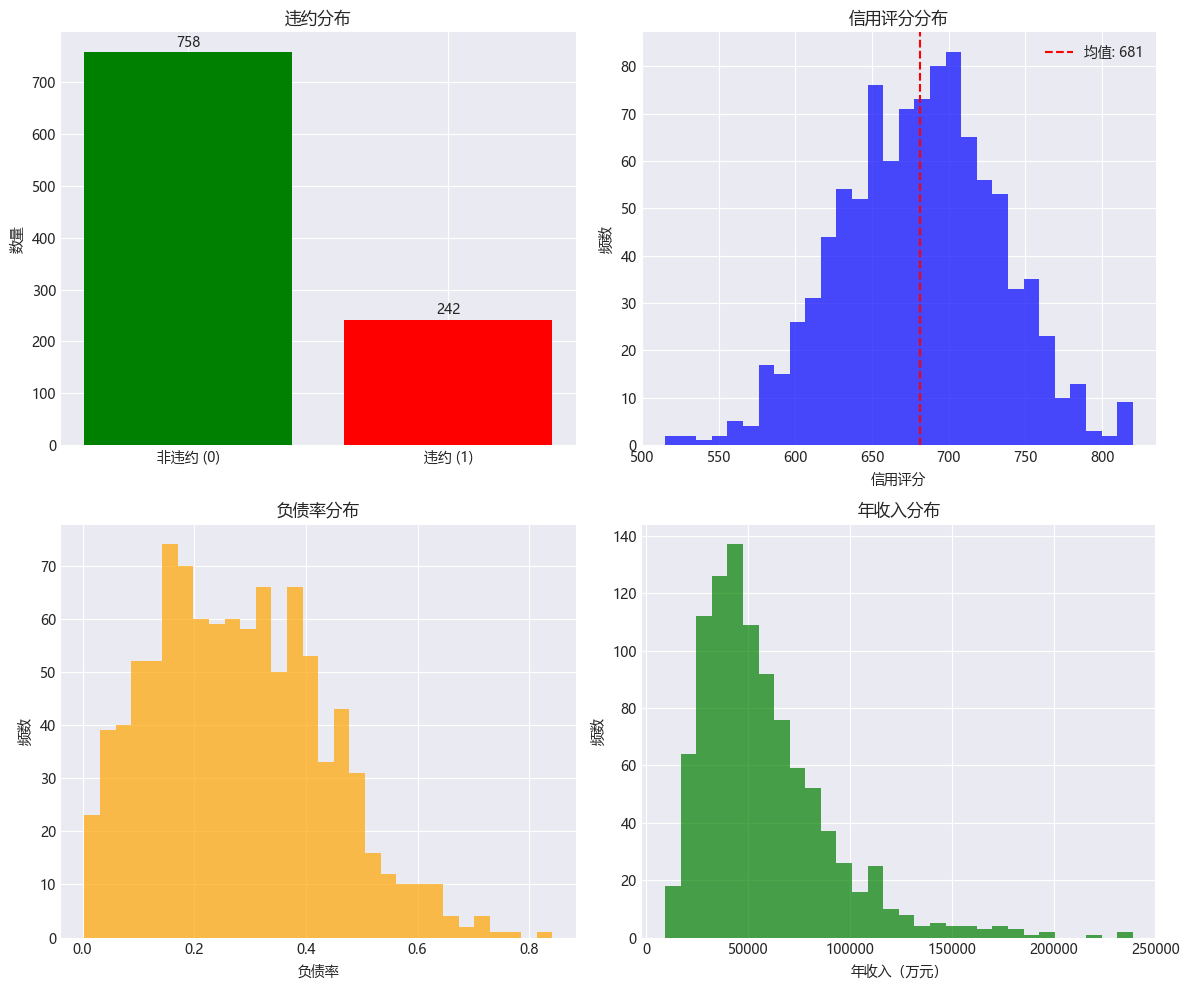

In [4]:
print("\n2. 探索性数据分析")
print("\n特征统计摘要:")
print(df.describe().round(2))

print("\n分类特征分布:")
print(df['employment_type'].value_counts())

# 可视化：违约率 vs 非违约率
fig, axes = plt.subplots(2, 2, figsize=(12, 10))

# 违约分布
ax1 = axes[0, 0]
default_counts = df['default'].value_counts()
ax1.bar(['非违约 (0)', '违约 (1)'], default_counts.values, color=['green', 'red'])
ax1.set_title('违约分布')
ax1.set_ylabel('数量')
for i, v in enumerate(default_counts.values):
    ax1.text(i, v + 10, str(v), ha='center')

# 信用评分分布
ax2 = axes[0, 1]
ax2.hist(df['credit_score'], bins=30, alpha=0.7, color='blue')
ax2.axvline(df['credit_score'].mean(), color='red', linestyle='--', label=f'均值: {df["credit_score"].mean():.0f}')
ax2.set_title('信用评分分布')
ax2.set_xlabel('信用评分')
ax2.set_ylabel('频数')
ax2.legend()

# 负债率分布
ax3 = axes[1, 0]
ax3.hist(df['debt_ratio'], bins=30, alpha=0.7, color='orange')
ax3.set_title('负债率分布')
ax3.set_xlabel('负债率')
ax3.set_ylabel('频数')

# 年收入分布
ax4 = axes[1, 1]
ax4.hist(df['income'], bins=30, alpha=0.7, color='green')
ax4.set_title('年收入分布')
ax4.set_xlabel('年收入（万元）')
ax4.set_ylabel('频数')

plt.tight_layout()
plt.show()

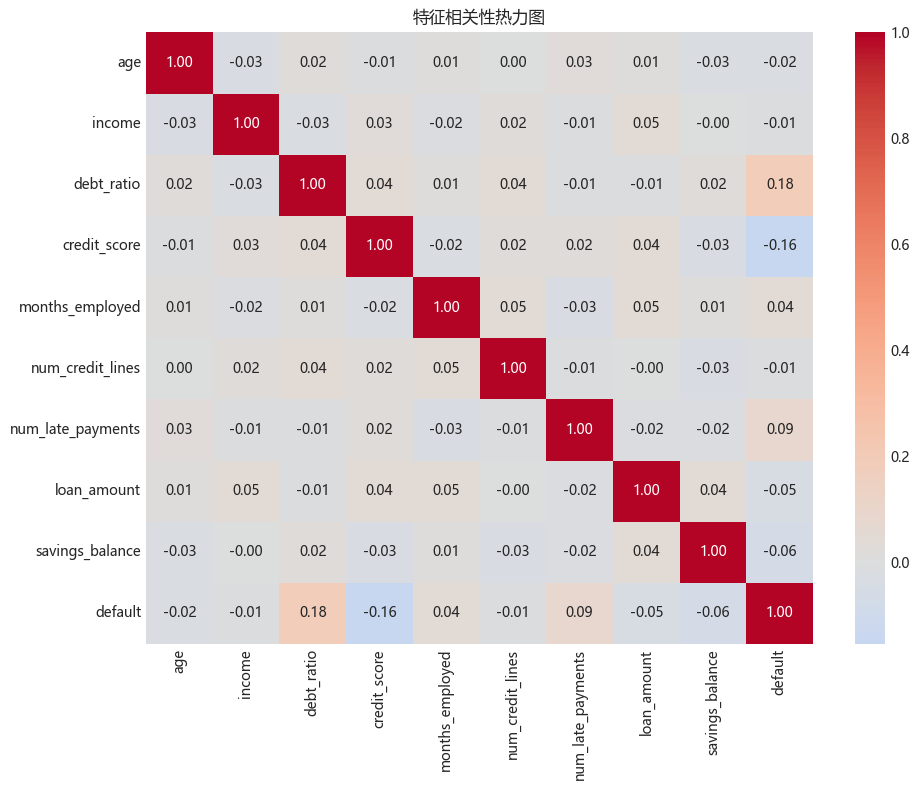

In [5]:
# 相关性热力图
plt.figure(figsize=(10, 8))
numeric_cols = df.select_dtypes(include=[np.number]).columns
corr_matrix = df[numeric_cols].corr()
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', center=0, fmt='.2f')
plt.title('特征相关性热力图')
plt.tight_layout()
plt.show()

## 3. 数据预处理

### 为什么建模前要做预处理

机器学习模型不能直接理解“雇佣类型”“学历”这类文字变量，也容易受到变量量纲影响。比如，年收入可能是几万到几十万，逾期次数可能只有 0 到几次。如果不做标准化，数值范围大的变量在某些模型中会显得更“重要”，但这种重要性可能只是量纲造成的。

这一节主要完成三件事：

1. **分离特征和目标变量**：`X` 是模型用来判断风险的信息，`y` 是要预测的违约结果。
2. **划分训练集和测试集**：训练集用于学习规律，测试集用于模拟模型面对新客户时的表现。这样可以避免模型只是在旧数据上表现好。
3. **构造预处理流水线**：数值变量做标准化，分类变量做独热编码。独热编码就是把一个类别变量拆成多个 0/1 指示变量。例如，`employment_type = 自雇` 可以变成一个单独的指示列。

一个直观类比是考试复习：训练集像平时练习题，测试集像正式考试。只看练习题成绩，不能判断是否真正掌握了规律。

In [6]:
print("\n3. 数据预处理")

# 分离特征和目标
X = df.drop('default', axis=1)
y = df['default']

# 识别数值特征和分类特征
numeric_features = ['age', 'income', 'debt_ratio', 'credit_score', 
                    'months_employed', 'num_credit_lines', 'num_late_payments',
                    'loan_amount', 'savings_balance']
categorical_features = ['employment_type']

# 预处理管道
preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numeric_features),
        ('cat', OneHotEncoder(drop='first'), categorical_features)
    ])

# 划分训练集和测试集
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y
)

print(f"训练集大小: {X_train.shape}")
print(f"测试集大小: {X_test.shape}")
print(f"训练集违约率: {y_train.mean():.2%}")
print(f"测试集违约率: {y_test.mean():.2%}")

# 预处理数据
X_train_processed = preprocessor.fit_transform(X_train)
X_test_processed = preprocessor.transform(X_test)

# 获取特征名称
feature_names = (numeric_features + 
                 list(preprocessor.named_transformers_['cat']
                      .get_feature_names_out(categorical_features)))
print(f"\n处理后的特征数量: {X_train_processed.shape[1]}")


3. 数据预处理
训练集大小: (700, 10)
测试集大小: (300, 10)
训练集违约率: 24.14%
测试集违约率: 24.33%

处理后的特征数量: 11


## 4. 正则化回归

### 正则化在这里解决什么问题

正则化的核心思想是给模型加约束，让它不要为了迎合训练集而把变量影响估得过于夸张。这样做通常会牺牲一点训练集表现，但可以换来更稳健的预测能力。

本节比较 Ridge、Lasso 和 Elastic Net。三者可以这样理解：

| 方法 | 直观作用 | 适合场景 |
|---|---|---|
| Ridge | 把很多系数整体压小，但通常不会压到 0 | 变量较多且彼此相关，希望模型更稳定 |
| Lasso | 可以把部分系数压成 0 | 希望自动筛选关键变量 |
| Elastic Net | 同时结合 Ridge 和 Lasso | 变量多、相关性强，同时还希望保留一定筛选能力 |

这里用回归模型处理 0/1 违约结果，主要是为了演示正则化思想。代码会把连续预测值按 0.5 阈值转成违约或不违约。在实际风控建模中，更常见的是使用带正则化的逻辑回归，因为它可以直接输出违约概率，更适合分类问题。

In [7]:
print("\n4. 正则化回归")

# 转换为 DataFrame 便于查看
X_train_df = pd.DataFrame(X_train_processed.toarray() if hasattr(X_train_processed, 'toarray') else X_train_processed,
                          columns=feature_names)
X_test_df = pd.DataFrame(X_test_processed.toarray() if hasattr(X_test_processed, 'toarray') else X_test_processed,
                         columns=feature_names)

# 4.1 Ridge 回归
print("\n4.1 Ridge 回归")
ridge = Ridge(alpha=1.0)
ridge.fit(X_train_processed, y_train)
ridge_pred = ridge.predict(X_test_processed)
ridge_pred_binary = (ridge_pred > 0.5).astype(int)
print(f"Ridge 测试集 R²: {ridge.score(X_test_processed, y_test):.4f}")
print(f"Ridge 测试集 RMSE: {np.sqrt(mean_squared_error(y_test, ridge_pred)):.4f}")


4. 正则化回归

4.1 Ridge 回归
Ridge 测试集 R²: 0.0750
Ridge 测试集 RMSE: 0.4127


In [ ]:
# 4.2 Lasso 回归
print("\n4.2 Lasso 回归")
lasso = Lasso(alpha=0.01)
lasso.fit(X_train_processed, y_train)
lasso_pred = lasso.predict(X_test_processed)
lasso_pred_binary = (lasso_pred > 0.5).astype(int)
print(f"Lasso 测试集 R²: {lasso.score(X_test_processed, y_test):.4f}")
print(f"Lasso 测试集 RMSE: {np.sqrt(mean_squared_error(y_test, lasso_pred)):.4f}")
print(f"Lasso 非零系数个数: {np.sum(lasso.coef_ != 0)}")

In [ ]:
# 4.3 Elastic Net
print("\n4.3 Elastic Net")
elastic = ElasticNet(alpha=0.01, l1_ratio=0.5)
elastic.fit(X_train_processed, y_train)
elastic_pred = elastic.predict(X_test_processed)
elastic_pred_binary = (elastic_pred > 0.5).astype(int)
print(f"Elastic Net 测试集 R²: {elastic.score(X_test_processed, y_test):.4f}")
print(f"Elastic Net 测试集 RMSE: {np.sqrt(mean_squared_error(y_test, elastic_pred)):.4f}")

In [ ]:
# 可视化系数比较
plt.figure(figsize=(12, 6))
coef_df = pd.DataFrame({
    '特征': feature_names,
    'Ridge': ridge.coef_,
    'Lasso': lasso.coef_,
    'Elastic Net': elastic.coef_
})
x = np.arange(len(feature_names))
width = 0.25
plt.bar(x - width, ridge.coef_, width, label='Ridge', alpha=0.8)
plt.bar(x, lasso.coef_, width, label='Lasso', alpha=0.8)
plt.bar(x + width, elastic.coef_, width, label='Elastic Net', alpha=0.8)
plt.xlabel('特征')
plt.ylabel('系数值')
plt.title('正则化回归系数比较')
plt.xticks(x, feature_names, rotation=45, ha='right')
plt.legend()
plt.tight_layout()
plt.show()

## 5. 降维方法

### 为什么需要降维

当变量很多、变量之间又高度相关时，模型可能会不稳定：同一类信息被多个变量重复表达，系数解释也会变困难。降维的做法，是把多个原始变量压缩成少数几个综合指标，再用这些综合指标建模。

本节展示两种方法：

| 方法 | 怎么压缩信息 | 与违约结果的关系 |
|---|---|---|
| PCR | 先用 PCA 提取最能解释特征方差的主成分，再做预测 | 提取成分时不直接看 `default` |
| PLS | 提取成分时同时考虑特征和 `default` 的关系 | 更强调对目标变量有用的信息 |

类比来看，PCR 像是把一份体检报告压缩成几个身体综合指标，重点保留总体差异；PLS 则是围绕“违约风险”这个问题挑选和组合指标，通常更贴近预测目标。

In [ ]:
print("\n5. 降维方法")

# 5.1 主成分回归 (PCR)
print("\n5.1 主成分回归 (PCR)")
pca = PCA(n_components=5)
X_train_pca = pca.fit_transform(X_train_processed)
X_test_pca = pca.transform(X_test_processed)

print(f"解释方差比例: {pca.explained_variance_ratio_.round(3)}")
print(f"累积解释方差: {np.sum(pca.explained_variance_ratio_):.3f}")

# 用主成分进行回归
pcr = LogisticRegression(max_iter=1000)
pcr.fit(X_train_pca, y_train)
pcr_pred = pcr.predict(X_test_pca)
print(f"PCR 准确率: {accuracy_score(y_test, pcr_pred):.4f}")

In [ ]:
# 5.2 偏最小二乘 (PLS)
print("\n5.2 偏最小二乘 (PLS)")
pls = PLSRegression(n_components=5)
pls.fit(X_train_processed, y_train)
pls_pred = pls.predict(X_test_processed)
pls_pred_binary = (pls_pred > 0.5).astype(int)
print(f"PLS R²: {pls.score(X_test_processed, y_test):.4f}")
print(f"PLS RMSE: {np.sqrt(mean_squared_error(y_test, pls_pred)):.4f}")

## 6. 分类评估指标

### 为什么不能只看准确率

信贷违约预测是分类问题，但不同错误的业务成本并不一样。把高风险客户误判为低风险，可能带来坏账；把低风险客户误判为高风险，则可能损失正常客户。因此，评估模型时要同时看多种指标。

| 指标 | 回答的问题 | 在信贷风控中的含义 |
|---|---|---|
| Accuracy | 总体预测对了多少 | 类别平衡时有用，类别不平衡时容易误导 |
| Precision | 被判为违约的人里，有多少真的违约 | 关注拦截名单是否精准 |
| Recall | 真实违约的人里，有多少被识别出来 | 关注漏掉了多少高风险客户 |
| F1 | Precision 和 Recall 的折中 | 两者都重要时使用 |
| AUC | 模型区分高低风险客户的能力 | 不依赖某个固定阈值，常用于评估风险排序能力 |

在风控场景中，Recall 偏低通常意味着漏掉了不少潜在违约客户；Precision 偏低则意味着误伤了较多正常客户。实际使用时，需要结合银行的风险偏好和业务成本来选择阈值。

In [ ]:
print("\n6. 分类评估指标")

# 使用逻辑回归作为基准模型
logreg = LogisticRegression(max_iter=1000, random_state=42)
logreg.fit(X_train_processed, y_train)
y_pred = logreg.predict(X_test_processed)
y_prob = logreg.predict_proba(X_test_processed)[:, 1]

In [ ]:
# 混淆矩阵
print("\n6.1 混淆矩阵")
cm = confusion_matrix(y_test, y_pred)
tn, fp, fn, tp = cm.ravel()
print(f"True Negatives (TN): {tn}")
print(f"False Positives (FP): {fp}")
print(f"False Negatives (FN): {fn}")
print(f"True Positives (TP): {tp}")

# 可视化混淆矩阵
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=['预测未违约', '预测违约'],
            yticklabels=['实际未违约', '实际违约'])
plt.title('混淆矩阵')
plt.ylabel('真实值')
plt.xlabel('预测值')
plt.show()

In [ ]:
# 6.2 分类指标
print("\n6.2 分类指标")
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

print(f"准确率 (Accuracy): {accuracy:.4f}")
print(f"精确率 (Precision): {precision:.4f}")
print(f"召回率 (Recall): {recall:.4f}")
print(f"F1 分数: {f1:.4f}")

In [ ]:
# 6.3 ROC 曲线和 AUC
print("\n6.3 ROC 曲线和 AUC")
fpr, tpr, thresholds = roc_curve(y_test, y_prob)
roc_auc = auc(fpr, tpr)
print(f"AUC: {roc_auc:.4f}")

plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC 曲线 (AUC = {roc_auc:.3f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--', label='随机猜测')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('假正率 (FPR)')
plt.ylabel('真正率 (TPR)')
plt.title('ROC 曲线')
plt.legend(loc="lower right")
plt.grid(True, alpha=0.3)
plt.show()

In [ ]:
# 6.4 精确率-召回率曲线
print("\n6.4 精确率-召回率曲线")
from sklearn.metrics import precision_recall_curve
precision_curve, recall_curve, _ = precision_recall_curve(y_test, y_prob)
pr_auc = auc(recall_curve, precision_curve)

plt.figure(figsize=(8, 6))
plt.plot(recall_curve, precision_curve, color='purple', lw=2, label=f'PR 曲线 (AUC = {pr_auc:.3f})')
plt.xlabel('召回率')
plt.ylabel('精确率')
plt.title('精确率-召回率曲线')
plt.legend(loc="lower left")
plt.grid(True, alpha=0.3)
plt.show()

## 7. 交叉验证与模型选择

### 交叉验证在防止什么问题

一次训练集和测试集划分可能带有偶然性：如果测试集刚好比较容易，模型分数会偏高；如果测试集刚好比较难，分数会偏低。交叉验证会多次划分训练和验证数据，从而得到更稳定的模型表现估计。

这一节有两个重点：

1. **比较不同模型的平均表现**：看模型在多次验证中的平均得分，而不是只看某一次划分。
2. **选择超参数**：例如 Lasso 的 `alpha` 控制正则化强度。`alpha` 太小，模型约束不足；`alpha` 太大，模型又可能过度简化，把重要信息也压掉。

可以把交叉验证理解成多场模拟考试：只考一次，运气成分可能很大；多考几次，才更能判断模型是否稳定。

In [ ]:
print("\n7. 交叉验证与模型选择")

# 7.1 不同模型的交叉验证对比
models = {
    'Logistic Regression': LogisticRegression(max_iter=1000, random_state=42),
    'Ridge': Ridge(alpha=1.0),
    'Lasso': Lasso(alpha=0.01),
    'Elastic Net': ElasticNet(alpha=0.01, l1_ratio=0.5)
}

cv_results = {}
for name, model in models.items():
    # 对于回归模型，转换为分类评估
    if name in ['Ridge', 'Lasso', 'Elastic Net']:
        scores = cross_val_score(model, X_train_processed, y_train, cv=5, scoring='r2')
        cv_results[name] = scores.mean()
        print(f"{name}: R² = {scores.mean():.4f} (±{scores.std():.4f})")
    else:
        scores = cross_val_score(model, X_train_processed, y_train, cv=5, scoring='accuracy')
        cv_results[name] = scores.mean()
        print(f"{name}: Accuracy = {scores.mean():.4f} (±{scores.std():.4f})")

In [ ]:
# 7.2 超参数调优：Lasso 的 alpha 选择
print("\n7.2 Lasso 超参数调优")
alphas = np.logspace(-4, 1, 20)
lasso_scores = []
for alpha in alphas:
    lasso = Lasso(alpha=alpha, max_iter=1000)
    scores = cross_val_score(lasso, X_train_processed, y_train, cv=5, scoring='r2')
    lasso_scores.append(scores.mean())

best_alpha = alphas[np.argmax(lasso_scores)]
print(f"最优 alpha: {best_alpha:.4f}")
print(f"最优 CV R²: {max(lasso_scores):.4f}")

plt.figure(figsize=(10, 6))
plt.semilogx(alphas, lasso_scores, 'b-', linewidth=2)
plt.xlabel('Alpha (正则化强度)')
plt.ylabel('交叉验证 R²')
plt.title('Lasso 回归：交叉验证得分 vs Alpha')
plt.axvline(x=best_alpha, color='r', linestyle='--', label=f'最优 alpha = {best_alpha:.4f}')
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()

In [ ]:
# 7.3 降维方法对比：PCR vs PLS
print("\n7.3 降维方法对比：PCR vs PLS")
n_components_range = range(1, 11)
pcr_scores = []
pls_scores = []

for n_comp in n_components_range:
    # PCR
    pca = PCA(n_components=n_comp)
    X_train_pca = pca.fit_transform(X_train_processed)
    pcr = LogisticRegression(max_iter=1000)
    pcr_cv = cross_val_score(pcr, X_train_pca, y_train, cv=5, scoring='accuracy')
    pcr_scores.append(pcr_cv.mean())
    
    # PLS
    pls = PLSRegression(n_components=n_comp)
    pls_cv = cross_val_score(pls, X_train_processed, y_train, cv=5, scoring='r2')
    pls_scores.append(pls_cv.mean())

plt.figure(figsize=(10, 6))
plt.plot(n_components_range, pcr_scores, 'b-o', label='PCR (Accuracy)')
plt.plot(n_components_range, pls_scores, 'r-s', label='PLS (R²)')
plt.xlabel('成分数')
plt.ylabel('交叉验证得分')
plt.title('PCR vs PLS：不同成分数的性能对比')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

## 8. 模型对比总结

### 如何读模型对比结果

模型对比不是简单地选分数最高的模型，而是同时考虑预测表现、稳定性、可解释性和业务落地成本。

阅读这一节时，可以按四个问题判断：

1. **预测能力是否足够**：测试集指标和交叉验证结果是否都比较稳定。
2. **是否容易解释**：逻辑回归、Ridge、Lasso 通常比复杂模型更容易向业务部门解释。
3. **变量是否可操作**：如果重要变量是信用评分、负债率、逾期次数，业务上可以据此调整审批和定价；如果变量很难解释，落地会更困难。
4. **误判成本是否可接受**：风控通常更关心漏判高风险客户，因此不能只看总体准确率。

所以，模型对比表更像是决策面板，而不是单一排名榜。最终选择哪个模型，要看它能否在预测效果和业务可解释性之间取得平衡。

In [ ]:
print("\n8. 模型对比总结")
print("\n各模型性能对比：")
comparison_df = pd.DataFrame({
    '模型': ['Logistic Regression', 'Ridge', 'Lasso', 'Elastic Net', 'PCR (5成分)', 'PLS (5成分)'],
    '测试集得分': [
        accuracy_score(y_test, y_pred),
        ridge.score(X_test_processed, y_test),
        lasso.score(X_test_processed, y_test),
        elastic.score(X_test_processed, y_test),
        accuracy_score(y_test, pcr_pred),
        pls.score(X_test_processed, y_test)
    ],
    '指标类型': ['Accuracy', 'R²', 'R²', 'R²', 'Accuracy', 'R²']
})
print(comparison_df.round(4))

print("\n最佳模型选择建议：")
print("1. 如果需要可解释性：Logistic Regression（系数可解释）")
print("2. 如果需要特征选择：Lasso（自动选择重要特征）")
print("3. 如果需要稳定性：Ridge（处理共线性）")
print("4. 如果需要降维：PLS（有监督降维，通常优于PCR）")

## 9. 业务建议

基于以上分析，可以从四个方面理解模型在信贷风控中的应用价值：

1. **关键风险因素**
   - 信用评分：通常是最重要的风险信号之一。
   - 负债率：反映客户偿债压力。
   - 逾期次数：直接体现历史履约情况。
   - 就业类型：例如自雇客户收入波动可能更大，需要结合其他变量判断。

2. **模型选择**
   - 生产环境：优先考虑逻辑回归或 Ridge 回归，结果相对稳定，也比较容易解释。
   - 特征探索：可以使用 Lasso 辅助识别关键风险因素。
   - 高维数据：如果变量很多、相关性强，可以考虑 PLS 降维。

3. **阈值调整**
   - 风控部门通常更重视召回率，可以适当降低阈值，减少漏判高风险客户。
   - 营销部门通常更重视精确率，可以适当提高阈值，减少对低风险客户的误伤。

4. **模型监控**
   - 定期监控 AUC、KS 值等模型表现指标。
   - 关注特征漂移，例如客户结构、收入水平或借款行为是否发生变化。
   - 根据新数据定期重新训练模型，避免模型长期失效。

### 如何理解最后的业务建议

最后一节把模型结果翻译成风控语言。它不只是技术总结，更是在回答：银行应该怎样使用这些结果？

可以把结论分成三类：

1. **风险识别**：哪些变量最能提示违约风险，例如信用评分、负债率和逾期次数。
2. **模型选择**：哪些模型适合解释，哪些模型适合筛选变量，哪些模型适合处理高维数据。
3. **策略落地**：如何调整审批阈值、风险定价和人工复核流程。

模型输出的是风险概率或风险排序，不是最终授信决策。真实业务还要结合合规要求、客户关系、抵押担保和人工审核。